# S-band (2-4 GHz) Radio Light Curve: SN 2018ivc vs. SN 2003bg vs. SN 2001ig

Spectral luminosity ($L_\nu$) vs. phase in the S-band / ~3 GHz range (2-4 GHz),
comparing SN 2018ivc to SN 2003bg and SN 2001ig. Modeled on
`radio_lc_IIb_comparison_Xband.ipynb`, restricted to these 3 objects and to S-band
instead of X-band, specifically to show late-time VLASS-era coverage.

**Data completeness note (2026-09-14):** VLASS/late-time S-band data was not in
`data/SN2003bg_radio_data.csv` or `data/SN2001ig_radio_data.csv` before this
notebook -- it existed only as hardcoded arrays in `vla_IIb_prop.ipynb` (never
previously merged into the per-SN CSVs). Pulled from there and appended to the CSVs:
- **SN2003bg**: 3 VLASS points (`sn2003bg_vlass_times/flux/rms` in
  `vla_IIb_prop.ipynb`), phases 5967.7/6931.0/7891.5 days, 3 GHz (VLASS nominal
  center frequency, matching the convention already used for SN2018ivc's own VLASS
  point in `radio_18ivc_data.csv`). Note: `vla_IIb_prop.ipynb` labels these times
  `#MJD` in a comment, but they are actually days post-explosion already (real MJD
  values that small would predate the 1990s; they match the "Time Since Explosion
  [days]" axis label used elsewhere in that notebook for the same arrays).
- **SN2001ig has no VLASS data anywhere in the repo.** Per the user's decision
  2026-09-14, included instead with its late-time ATCA data (Soria et al. 2025,
  `sn2001ig_atca_*` arrays in `vla_IIb_prop.ipynb`), phases 4199-8172 days,
  2.1/5.5/9.0 GHz -- a different survey/band than VLASS, not a substitute, so it's
  labeled as ATCA (not VLASS) throughout this notebook.

Frequency window: **2-4 GHz**, matching VLASS's actual S-band coverage (not a bare
"3.0 GHz exactly" cut) -- this is what actually picks up SN2001ig's existing
2.368/2.496 GHz literature points and its new 2.1 GHz ATCA points alongside the
3.0 GHz VLASS points for the other two objects.

Flux density is converted to spectral luminosity ($L_\nu = 4\pi D^2 F_\nu$) using
the same per-SN distances as `radio_lc_IIb_comparison_Xband.ipynb`
(`data/sn_reference_crosswalk.xlsx`, "Figure 8 References" sheet) -- SN2018ivc uses
the 10.72 Mpc Cepheid distance to stay consistent with that sibling figure, not the
10 Mpc Maeda+2023b distance adopted later for the X-ray work
(`CLAUDE_xray_SOP.md`/`CLAUDE_modelling_SOP.md`); flag if these should be
reconciled project-wide.

Color encodes SN identity (categorical palette), reusing the exact same per-SN
colors as `radio_lc_IIb_comparison_Xband.ipynb` (SN2003bg / SN2001ig keep their
colors from that figure's `COMPARISON_SNE` ordering) so the two comparison figures
stay visually consistent. SN2018ivc keeps its distinct star marker/black color.

**Update 2026-09-15 -- SN2003bg L-band supplement.** SN2003bg has no VLA/VLASS
coverage anywhere between 1.4 and 4.86 GHz before its 3 late VLASS points
(day ~5968+) -- confirmed by exhaustively checking `vla_IIb_prop.ipynb` and its
source CSV, no true early-time S-band data exists for this object. Per the user's
decision 2026-09-15, SN2003bg's early-time comparator is widened to include its
1.4 GHz (L-band) points instead (`SN2003bg_one` in `vla_IIb_prop.ipynb` / the
`freq==1.4` rows already in `data/SN2003bg_radio_data.csv`) -- this is a
band-widening for SN2003bg specifically, not a global change to `SBAND_LO/HI`
(SN2001ig and SN2018ivc both already have genuine 2-4 GHz coverage and are
unaffected). These supplementary L-band points are drawn as **hollow** markers
(same per-SN color, unfilled) to visually distinguish them from true S-band
points -- filled markers are true 2-4 GHz data throughout, for all 3 objects.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import functions

functions.set_plot_style()

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

# --- This comparison: SN2018ivc vs SN2003bg vs SN2001ig, S-band only ---
COMPARISON_SNE = ["SN2003bg", "SN2001ig"]
ALL_SNE = COMPARISON_SNE + ["SN2018ivc"]

SBAND_LO, SBAND_HI = 2.0, 4.0  # GHz -- VLASS's actual bandpass, not a bare 3.0 GHz cut

# SN2003bg-specific widening (see markdown note above): no true S-band data exists
# for this object before its late VLASS points, so its early-time comparator is its
# 1.4 GHz (L-band) coverage instead. Flagged via `is_sband` so plotting can render
# these as hollow markers, distinct from genuine 2-4 GHz points.
LBAND_SUPPLEMENT = {"SN2003bg": 1.43}  # matches data/SN2003bg_radio_data.csv's stored value

# --- Load per-SN distances from the reference crosswalk (same source/sheet as
# radio_lc_IIb_comparison_Xband.ipynb) ---
crosswalk = pd.read_excel(
    "../data/sn_reference_crosswalk.xlsx", sheet_name="Figure 8 References"
)
crosswalk["SN_key"] = crosswalk["Supernova"].str.replace(" ", "", regex=False)
dist_lookup = crosswalk.set_index("SN_key")["distance_Mpc"].to_dict()

for sn in ALL_SNE:
    assert sn in dist_lookup and not pd.isna(dist_lookup[sn]), f"missing distance for {sn}"

# --- Load and filter S-band data for every SN in the comparison, plus any
# SN-specific L-band supplement ---
frames = []
for sn in ALL_SNE:
    fname = "../data/radio_18ivc_data.csv" if sn == "SN2018ivc" else f"../data/{sn}_radio_data.csv"
    df_full = pd.read_csv(fname)

    df_sband = df_full[(df_full["freq"] >= SBAND_LO) & (df_full["freq"] < SBAND_HI)].copy()
    df_sband["is_sband"] = True

    parts = [df_sband]
    if sn in LBAND_SUPPLEMENT:
        df_lband = df_full[np.isclose(df_full["freq"], LBAND_SUPPLEMENT[sn])].copy()
        df_lband["is_sband"] = False
        parts.append(df_lband)

    df = pd.concat(parts, ignore_index=True)
    df["SN"] = sn
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

print(data.groupby(["SN", "telescope", "is_sband"]).size())

SN         telescope  is_sband
SN2001ig   ATCA       True        26
SN2003bg   VLA        False       31
           VLASS      True         3
SN2018ivc  VLA        True         5
           VLASS      True         1
dtype: int64


In [2]:
# --- Flux density -> spectral luminosity ---
MPC_TO_CM = 3.0857e24
MJY_TO_ERG_S_CM2_HZ = 1e-26

def flux_to_luminosity(flux_mjy, distance_mpc):
    F_nu = flux_mjy * MJY_TO_ERG_S_CM2_HZ
    D_cm = distance_mpc * MPC_TO_CM
    return 4 * np.pi * D_cm**2 * F_nu

data["distance_Mpc"] = data["SN"].map(dist_lookup)
data["L_nu"] = flux_to_luminosity(data["flux"], data["distance_Mpc"])
data["L_nu_err"] = flux_to_luminosity(data["flux_err"].fillna(0), data["distance_Mpc"])

data.sort_values(["SN", "phase"])

,phase,freq,flux,flux_err,telescope,is_sband,SN,distance_Mpc,L_nu,L_nu_err
34,28.0,2.496,4.600,NaN,ATCA,True,SN2001ig,11.50,7.278984e+26,0.000000e+00
35,48.0,2.496,5.300,0.300000,ATCA,True,SN2001ig,11.50,8.386656e+26,4.747164e+25
36,85.0,2.496,11.500,0.300000,ATCA,True,SN2001ig,11.50,1.819746e+27,4.747164e+25
37,106.0,2.496,25.100,1.300000,ATCA,True,SN2001ig,11.50,3.971794e+27,2.057104e+26
38,115.0,2.496,23.500,0.300000,ATCA,True,SN2001ig,11.50,3.718611e+27,4.747164e+25
...,...,...,...,...,...,...,...,...,...,...
61,2155.0,3.000,6.220,1.772705,VLA,True,SN2018ivc,10.72,8.552581e+26,2.437493e+26
62,2471.0,3.000,16.200,1.878004,VLA,True,SN2018ivc,10.72,2.227521e+27,2.582280e+26
63,2529.0,3.000,17.770,1.875561,VLA,True,SN2018ivc,10.72,2.443398e+27,2.578921e+26
64,2561.0,3.000,13.478,1.980000,VLASS,True,SN2018ivc,10.72,1.853243e+27,2.722526e+26


In [3]:
# --- Style setup: color by SN identity, reusing the exact colors from
# radio_lc_IIb_comparison_Xband.ipynb's COMPARISON_SNE ordering so both figures
# stay visually consistent for SN2003bg/SN2001ig ---
XBAND_COMPARISON_SNE = ["SN1993J", "SN2003bg", "SN2001ig", "SN2016gkg", "SN2001gd", "SN2011hs"]
tab10 = mpl.colormaps["tab10"]
SN_COLOR = {sn: tab10(i) for i, sn in enumerate(XBAND_COMPARISON_SNE)}
SN_COLOR["SN2018ivc"] = "#000000"  # reserved: solid black, maximally distinct from tab10

COMPARISON_MS = 8
COMPARISON_MARKER = "o"


def plot_comparison_sne(ax, ms_scale=1.0):
    for sn in COMPARISON_SNE:
        color = SN_COLOR[sn]
        edge = darken_color(color, 0.7)

        d_s = data[(data["SN"] == sn) & (data["is_sband"])].sort_values("phase")
        ax.errorbar(
            d_s["phase"], d_s["L_nu"], yerr=d_s["L_nu_err"],
            fmt=COMPARISON_MARKER, ms=COMPARISON_MS * ms_scale,
            capsize=3 * ms_scale, elinewidth=1.3 * ms_scale,
            linestyle="none", color=color, markeredgecolor=edge,
            alpha=0.85, label=sn, zorder=3,
        )

        # SN-specific L-band supplement (e.g. SN2003bg, see markdown note): hollow
        # markers, same color family, excluded from the main legend entry.
        d_l = data[(data["SN"] == sn) & (~data["is_sband"])].sort_values("phase")
        if len(d_l):
            ax.errorbar(
                d_l["phase"], d_l["L_nu"], yerr=d_l["L_nu_err"],
                fmt=COMPARISON_MARKER, ms=COMPARISON_MS * ms_scale,
                capsize=3 * ms_scale, elinewidth=1.3 * ms_scale,
                linestyle="none", color="none", markeredgecolor=edge,
                markeredgewidth=1.4 * ms_scale, alpha=0.85, zorder=3,
            )


def plot_2018ivc(ax, marker="*", ms=24, markeredgewidth=1.2, ms_scale=1.0):
    d_sn = data[data["SN"] == "SN2018ivc"].sort_values("phase")
    color = SN_COLOR["SN2018ivc"]
    ax.errorbar(
        d_sn["phase"], d_sn["L_nu"], yerr=d_sn["L_nu_err"],
        fmt=marker, ms=ms * ms_scale,
        capsize=4 * ms_scale, elinewidth=1.8 * ms_scale,
        markeredgewidth=markeredgewidth, linestyle="none",
        color=color, markeredgecolor="0.3",
        alpha=0.95, label="SN2018ivc", zorder=5,
    )

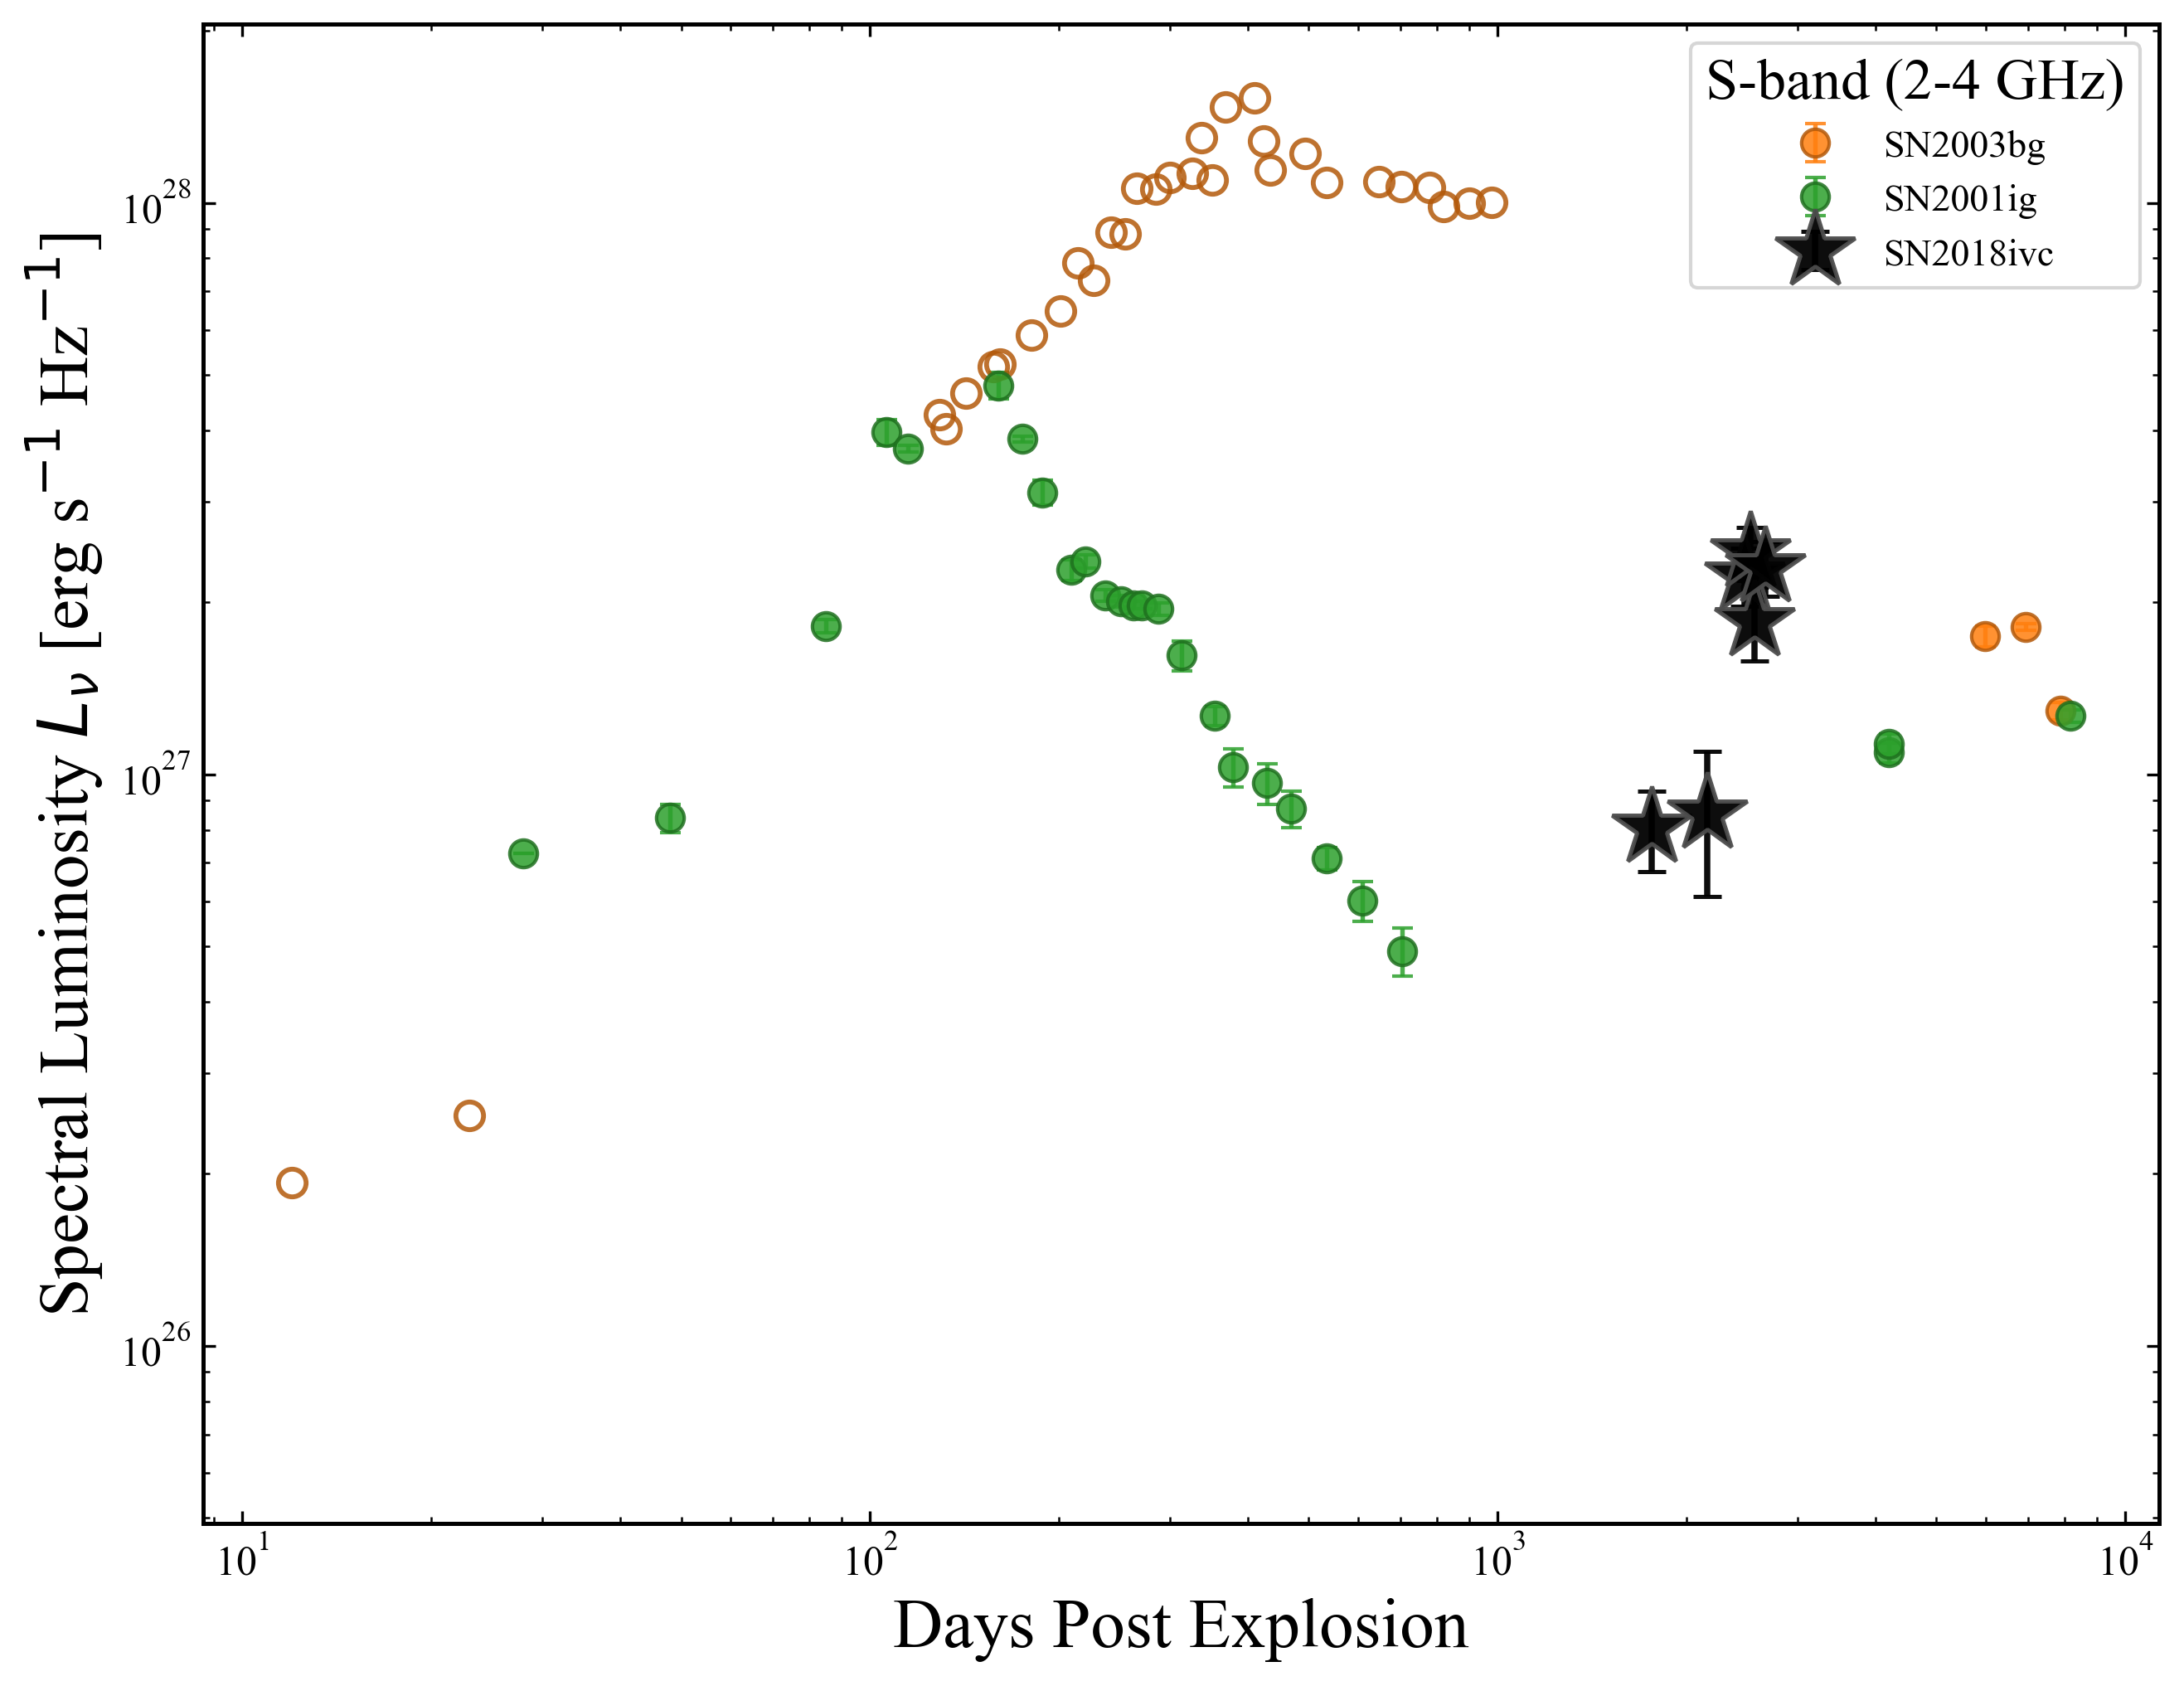

In [4]:
fig, ax = plt.subplots(dpi=300, figsize=(9, 7))

plot_comparison_sne(ax)
plot_2018ivc(ax)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Days Post Explosion", fontsize=20)
ax.set_ylabel(r"Spectral Luminosity $L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]", fontsize=20)

ax.legend(title="S-band (2-4 GHz)", title_fontsize="large", fontsize=11, frameon=True)

fig.tight_layout()

fig.savefig("../figures/radio_lc_IIb_comparison_Sband.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/radio_lc_IIb_comparison_Sband.pdf", bbox_inches="tight")

plt.show()
